## Implementacja kd-drzewa (kd-tree)

In [34]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

In [35]:
from visualizer.main import Visualizer
import numpy as np
import matplotlib.pyplot as plt

Funkcje pomocnicze służące do wczytywania zbioru punktów za pomocą myszki.

In [147]:
%matplotlib tk

events = []
points = []
active = True

def draw_point(point) -> None:
    plt.scatter(point[0], point[1], color="red")
    plt.show()
    
def onclick(event) -> None:
    global active
    if event.button == 1 and active:
        x, y = event.xdata, event.ydata
        new_point = (x, y)
        points.append(new_point)
        draw_point(new_point)
    elif event.button == 3:
        active = False
        plt.pause(1)
        plt.close()
        
fig, ax = plt.subplots()
plt.get_current_fig_manager().set_window_title("Umieszczanie punktów na płaszczyźnie")
ax.set_title("LPM: Dodanie punktu\nPPM: Zakończenie")
connection_id = fig.canvas.mpl_connect("button_press_event", onclick)
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
plt.tight_layout()
plt.ion()
plt.show()  

[(np.float64(2.375564241888834), np.float64(6.488704579067945)), (np.float64(3.711592221025498), np.float64(3.617724675927267)), (np.float64(4.78041460433483), np.float64(7.028100803294376)), (np.float64(5.326443430590684), np.float64(3.6003247977264143)), (np.float64(7.045853351566565), np.float64(7.289098976307165)), (np.float64(6.616000871322595), np.float64(3.060928573499984)), (np.float64(5.721443007031089), np.float64(8.037293738943827)), (np.float64(4.025268355257585), np.float64(5.5143113998202)), (np.float64(4.582914816114627), np.float64(5.6535104254270205)), (np.float64(3.47923952900173), np.float64(8.280892033755762)), (np.float64(6.4185010831023925), np.float64(5.723109938230431)), (np.float64(4.699091162126511), np.float64(2.190934663457355))]


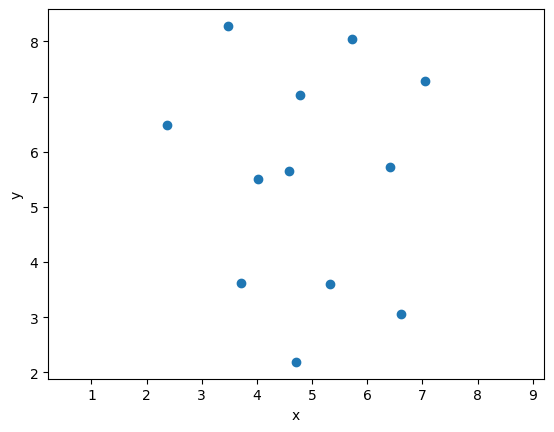

In [37]:
%matplotlib inline
print(points)
vis = Visualizer()
vis.axis_equal()
vis.add_point(points)
vis.show()

Implementacja kd-drzew (kd-tree).

In [168]:
class Node:
    def __init__(self, point, axis = 0, left = None, right = None):
        self.point = point
        self.axis = axis
        self.left = left
        self.right = right
        
    def get_subtree_points(self):
        points = [self.point]

        if self.left is not None:
            points += self.left.get_subtree_points()
        if self.right is not None:
            points += self.right.get_subtree_points()
            
        return points

    def __repr__(self):
        return f"({self.point[0]}, {self.point[1]}), {'x' if self.axis == 0 else 'y'}"
    
class Kdtree:
    def build_kdtree(self, points, depth = 0):
        axis = depth % self.k
        n = len(points[axis])
        
        if n < 1:
            return None
        if n == 1:
            return Node(points[axis][0], axis = depth % self.k)
        
        median = points[axis][n // 2]
        
        left, right = [[] for _ in range(self.k)], [[] for _ in range(self.k)]
        
        for i in range(self.k):
            for p in points[i]:
                if p == median:
                    continue
                if p[axis] < median[axis]:
                    left[i].append(p)
                else:
                    right[i].append(p)
        
        return Node(
            point = median,
            axis = axis,
            left = self.build_kdtree(left, depth + 1),
            right = self.build_kdtree(right, depth + 1)
        )
        
    def __init__(self, points, k = 2):
        self.points = points
        self.k = k
        
        P = [sorted(points, key = lambda x: x[i]) for i in range(k)]
        
        self.root = self.build_kdtree(P)
    
    def contains(self, node_region, query_region):
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        return xmin <= x1 and x2 <= xmax and ymin <= y1 and y2 <= ymax
        
    def intersects(self, node_region, query_region):
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        return not (xmin > x2 or x1 > xmax or ymin > y2 or y1 > ymax)
       
    def search(self, node: Node, node_region, query_region, result):
        if not node:
            return
        
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        x, y = node.point
        
        if xmin <= x <= xmax and ymin <= y <= ymax:
            result.append(node.point)
            
        if node.axis == 0:
            left_region = [x1, x, y1, y2]
            right_region = [x, x2, y1, y2]
        else:
            left_region = [x1, x2, y1, y]
            right_region = [x1, x2, y, y2]
                        
        if node.left:  
            if self.contains(left_region, query_region):
                result.extend(node.left.get_subtree_points())
            elif self.intersects(left_region, query_region):
                self.search(node.left, left_region, query_region, result)
        
        if node.right:
            if self.contains(right_region, query_region):
                result.extend(node.right.get_subtree_points())
            elif self.intersects(right_region, query_region):
                self.search(node.right, right_region, query_region, result)

Wizualizacja kd-drzewa (kd-tree).

In [169]:
def traverse(root: Node, vis: Visualizer, xmin = 0, xmax = 10, ymin = 0, ymax = 10) -> None:
    area = [(xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)]
    to_remove = vis.add_polygon(area, alpha = 0.5, color="grey")
    vis.remove_figure(to_remove)
    
    if not root:
        return

    x, y = root.point
    
    if root.axis == 0:
        vis.add_line_segment(((x, ymin), (x, ymax)), color="green")
        
        traverse(root.left, vis, xmin, x, ymin, ymax)
        traverse(root.right, vis, x, xmax, ymin, ymax)
        
    else:
        vis.add_line_segment(((xmin, y), (xmax, y)), color="green")
        
        traverse(root.left, vis, xmin, xmax, ymin, y)
        traverse(root.right, vis, xmin, xmax, y, ymax)
        

def kdtree_vis(kdtree: Kdtree) -> Visualizer:
    vis = Visualizer()
    
    vis.add_point(kdtree.points, color="blue")
    
    root = kdtree.root
    
    traverse(root, vis)
    
    return vis

Przykładowy zbiór punktów.

In [200]:
points = [(5, 5), (3, 7), (6, 3), (8, 8), (9, 9), (2, 3), (10, 1)]
kdtree = Kdtree(points)

default_region = (0, 10, 0, 10)
query_region = (1, 8, 1, 6)

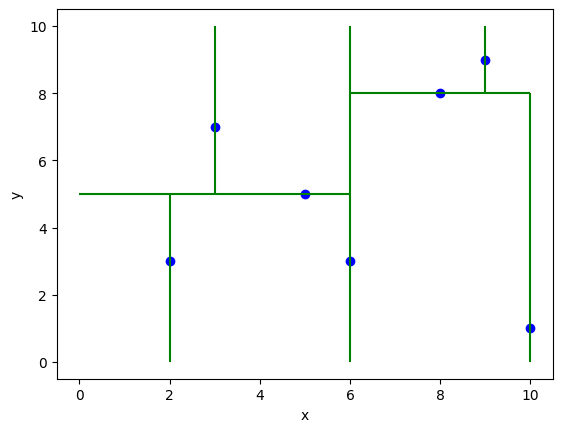

In [201]:
%matplotlib inline
vis = kdtree_vis(kdtree)
vis.show()

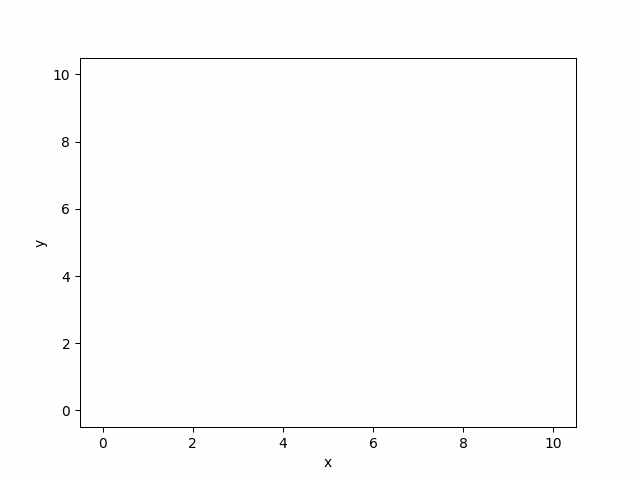

In [202]:
%matplotlib inline
vis.show_gif()

Znajdowanie punktów należących do zadanego obszaru w kształcie prostokąta.

In [203]:
def search(kdtree: Kdtree, query_region, node_region):
    result = []
    kdtree.search(kdtree.root, node_region, query_region, result)
    return result

In [204]:
tree = Kdtree(points)
result = search(tree, query_region, default_region)
print(result)

[(6, 3), (5, 5), (2, 3)]


Wizualizacja zbioru punktów należących do zadanego regionu.

In [205]:
def search_vis(tree: Kdtree, query_region, node_region):
    xmin, xmax, ymin, ymax = query_region
    
    vis = kdtree_vis(tree)
    
    query_area = [(xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)]
    vis.add_polygon(query_area, alpha = 0.5, color="grey")
    
    found_points = []
    tree.search(tree.root, node_region, query_region, found_points)
    
    vis.add_point(found_points, color="red")
    
    return vis
    

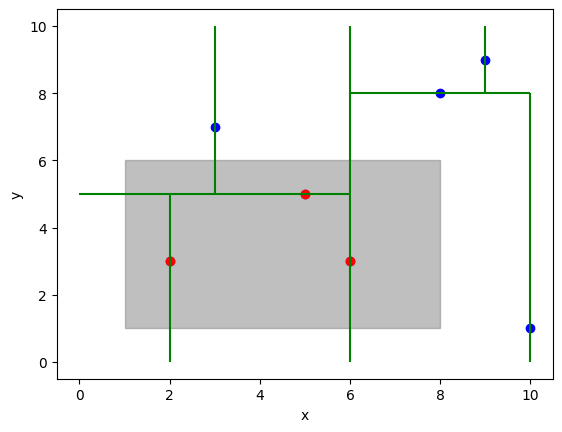

In [206]:
vis = search_vis(kdtree, query_region, default_region)
vis.show()

Wizualizacja poszczególnych kroków szukania punktów należących do zadanego regionu.